# Bibliotecas

In [25]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [26]:
def score_combinado(estimator, X, y):
    y_pred = estimator.predict(X)
    y_proba = estimator.predict_proba(X)

    auc = roc_auc_score(
        y,
        y_proba,
        multi_class="ovr",
        average="macro"
    )

    sensibilidade = recall_score(
        y,
        y_pred,
        average="macro"
    )

    return 0.4 * auc + 0.6 * sensibilidade

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def matriz_confusao_obsidade(conjunto, model, y_real, y_pred):

    classes = model.classes_

    cm_absoluta = confusion_matrix(
        y_real.squeeze(),
        y_pred,
        labels=classes
    )

    cm_normalizada = confusion_matrix(
        y_real.squeeze(),
        y_pred,
        labels=classes,
        normalize="true"
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(
        cm_absoluta,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        ax=axes[0]
    )

    axes[0].set_title(f"Matriz de confusão — {conjunto}")
    axes[0].set_xlabel("Classe predita")
    axes[0].set_ylabel("Classe real")

    sns.heatmap(
        cm_normalizada,
        annot=True,
        fmt=".1%",
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=classes,
        yticklabels=classes,
        ax=axes[1]
    )

    axes[1].set_title("Matriz normalizada por classe real")
    axes[1].set_xlabel("Classe predita")
    axes[1].set_ylabel("Classe real")

    plt.tight_layout()
    plt.show()

# Modelagem Baseline

In [3]:
output_dir = "bases_preparadas"

X_train = pd.read_csv(f"{output_dir}/X_train.csv")
y_train = pd.read_csv(f"{output_dir}/y_train.csv")

X_val = pd.read_csv(f"{output_dir}/X_val.csv")
y_val = pd.read_csv(f"{output_dir}/y_val.csv")

In [4]:
## Criando Features

def create_features(df):
    df = df.copy()

    cols_to_round = ["FCVC", "NCP", "CH2O", "FAF", "TUE"]

    for col in cols_to_round:
        if col in df.columns:
            df[col] = df[col].round().astype(int)

    df["flag_female"] = df["Gender"].map({"Female": 1, "Male": 0})
    df = df.drop(columns=["Gender"])

    df["flag_family_history"] = df["family_history"].map({"yes": 1, "no": 0})
    df = df.drop(columns=["family_history"])

    df["flag_FAVC"] = df["FAVC"].map({"yes": 1, "no": 0})
    df = df.drop(columns=["FAVC"])

    df["flag_SMOKE"] = df["SMOKE"].map({"yes": 1, "no": 0})
    df = df.drop(columns=["SMOKE"])

    df["flag_SCC"] = df["SCC"].map({"yes": 1, "no": 0})
    df = df.drop(columns=["SCC"])

    df["flag_active_transport"] = (df["MTRANS"].isin(["Bike", "Walking"])).astype(int)

    mapa_frequencia = {
        "no": 0,
        "Sometimes": 1,
        "Frequently": 2,
        "Always": 3
    }

    df["CAEC_freq"] = df["CAEC"].map(mapa_frequencia)
    df["CALC_freq"] = df["CALC"].map(mapa_frequencia)

    df = df.drop(columns=["CAEC", "CALC"])

    colunas_categoricas = ["MTRANS"]

    df = pd.get_dummies(df, columns=colunas_categoricas, dtype=int)

    # IMC
    df["BMI"] = df["Weight"] / (df["Height"] ** 2)

    # Interação IMC x idade
    df["BMI_x_Age"] = df["BMI"] * df["Age"]

    # Score de sedentarismo
    df["sedentary_score"] = (
        (3-df["FAF"]) +
        df["TUE"] +
        df["MTRANS_Automobile"] +
        df["MTRANS_Motorbike"] +
        df["MTRANS_Public_Transportation"] 
    )

    # Score de proteção por atividade
    df["activity_protection_score"] = (
        df["FAF"] +
        df["flag_active_transport"]
    )

    return df

X_train = create_features(X_train)
X_val = create_features(X_val)

## Colunas removidas 
### high_dominance: ['MTRANS_Bike', 'MTRANS_Motorbike']
### cols_to_drop_spearman = ["FAF", "Weight"]
### cols_to_drop_spearman_target = ["TUE", "NCP"]

X_train = X_train.drop(columns=["MTRANS_Bike", "MTRANS_Motorbike", "FAF", "Weight", "TUE", "NCP"])
X_val = X_val.drop(columns=["MTRANS_Bike", "MTRANS_Motorbike", "FAF", "Weight", "TUE", "NCP"])

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

rf_baseline = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    n_estimators=100,
    criterion='gini',
    max_depth=8,
    min_samples_leaf=0.02,
    bootstrap=True
)

rf_baseline.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",0.02
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
y_pred_train = rf_baseline.predict(X_train)
y_pred_val = rf_baseline.predict(X_val)

print("Treino")
print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("F1 macro:", f1_score(y_train, y_pred_train, average="macro"))

print("\nValidação")
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("F1 macro:", f1_score(y_val, y_pred_val, average="macro"))

print("\n",classification_report(y_val, y_pred_val))

Treino
Accuracy: 0.9438356164383561
F1 macro: 0.9407521959998608

Validação
Accuracy: 0.8945686900958466
F1 macro: 0.8912136993440695

               precision    recall  f1-score   support

           1       0.90      0.93      0.91        40
           2       0.76      0.81      0.79        43
           3       0.86      0.76      0.81        42
           4       0.88      0.88      0.88        43
           5       0.96      0.92      0.94        53
           6       0.89      0.95      0.92        44
           7       0.98      0.98      0.98        48

    accuracy                           0.89       313
   macro avg       0.89      0.89      0.89       313
weighted avg       0.90      0.89      0.89       313



In [14]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_baseline.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance)

unused_features = feature_importance.query("importance == 0")["feature"].tolist()

print("Quantidade de variáveis não utilizadas:", len(unused_features))
print(unused_features)

,feature,importance
15,BMI,0.400199
16,BMI_x_Age,0.217572
4,flag_female,0.089205
0,Age,0.076750
2,FCVC,0.042511
1,Height,0.041873
5,flag_family_history,0.036665
11,CALC_freq,0.027674
10,CAEC_freq,0.020905
13,MTRANS_Public_Transportation,0.011539


Quantidade de variáveis não utilizadas: 4
['flag_active_transport', 'flag_SCC', 'flag_SMOKE', 'MTRANS_Walking']


Quantidade de variáveis não utilizadas: 4
['flag_active_transport', 'flag_SCC', 'flag_SMOKE', 'MTRANS_Walking']

# Modelagem Otimizada

In [87]:
output_dir = "bases_preparadas"

X_train_xgb = pd.read_csv(f"{output_dir}/X_train.csv")
y_train_xgb = pd.read_csv(f"{output_dir}/y_train.csv")

X_val_xgb = pd.read_csv(f"{output_dir}/X_val.csv")
y_val_xgb = pd.read_csv(f"{output_dir}/y_val.csv")

In [84]:
## Criando Features

def create_features(df):
    df = df.copy()

    cols_to_round = ["FCVC", "NCP", "CH2O", "FAF", "TUE"]

    for col in cols_to_round:
        if col in df.columns:
            df[col] = df[col].round().astype(int)

    df["flag_female"] = df["Gender"].map({"Female": 1, "Male": 0})
    df = df.drop(columns=["Gender"])

    df["flag_family_history"] = df["family_history"].map({"yes": 1, "no": 0})
    df = df.drop(columns=["family_history"])

    df["flag_FAVC"] = df["FAVC"].map({"yes": 1, "no": 0})
    df = df.drop(columns=["FAVC"])

    df["flag_SMOKE"] = df["SMOKE"].map({"yes": 1, "no": 0})
    df = df.drop(columns=["SMOKE"])

    df["flag_SCC"] = df["SCC"].map({"yes": 1, "no": 0})
    df = df.drop(columns=["SCC"])

    df["flag_active_transport"] = (df["MTRANS"].isin(["Bike", "Walking"])).astype(int)

    mapa_frequencia = {
        "no": 0,
        "Sometimes": 1,
        "Frequently": 2,
        "Always": 3
    }

    df["CAEC_freq"] = df["CAEC"].map(mapa_frequencia)
    df["CALC_freq"] = df["CALC"].map(mapa_frequencia)

    df = df.drop(columns=["CAEC", "CALC"])

    colunas_categoricas = ["MTRANS"]

    df = pd.get_dummies(df, columns=colunas_categoricas, dtype=int)

    # IMC
    df["BMI"] = df["Weight"] / (df["Height"] ** 2)

    # Interação IMC x idade
    df["BMI_x_Age"] = df["BMI"] * df["Age"]

    # Score de sedentarismo
    df["sedentary_score"] = (
        (3-df["FAF"]) +
        df["TUE"] +
        df["MTRANS_Automobile"] +
        df["MTRANS_Motorbike"] +
        df["MTRANS_Public_Transportation"] 
    )

    # Score de proteção por atividade
    df["activity_protection_score"] = (
        df["FAF"] +
        df["flag_active_transport"]
    )
    
    return df

X_train_xgb = create_features(X_train_xgb)
X_val_xgb = create_features(X_val_xgb)

## Colunas removidas 
### high_dominance: ['MTRANS_Bike', 'MTRANS_Motorbike']
### cols_to_drop_spearman = ["FAF", "Weight"]
### cols_to_drop_spearman_target = ["TUE", "NCP"]
### variáveis não utilizadas no modelo baseline: ['flag_active_transport', 'flag_SCC', 'flag_SMOKE', 'MTRANS_Walking']

In [44]:
colunas_a_dropar = [
#  'Age',
#  'BMI',
 'BMI_x_Age',
#  'CAEC_freq',
#  'CALC_freq',
 'CH2O',
 'FAF',
#  'FCVC',
 'Height',
 'MTRANS_Automobile',
 'MTRANS_Bike',
 'MTRANS_Motorbike',
#  'MTRANS_Public_Transportation',
 'MTRANS_Walking',
 'NCP',
 'TUE',
 'Weight',
 'activity_protection_score',
 'flag_FAVC',
 'flag_SCC',
 'flag_SMOKE',
 'flag_active_transport',
#  'flag_family_history',
#  'flag_female',
 'sedentary_score'
]

X_train_xgb = X_train_xgb.drop(
    columns=colunas_a_dropar,
    errors="ignore"
)

X_val_xgb = X_val_xgb.drop(
    columns=colunas_a_dropar,
    errors="ignore"
)

In [45]:
display(X_train_xgb.shape)
display(y_train_xgb.shape)
display(X_val_xgb.shape)
display(y_val_xgb.shape)

(1460, 10)

(1460, 1)

(313, 10)

(313, 1)

In [46]:
X_train_xgb, X_val_xgb = X_train_xgb.align(
    X_val_xgb,
    join="left",
    axis=1,
    fill_value=0
)

In [47]:
## O resultado deve ser uma série vazia
display(X_train_xgb.select_dtypes(exclude=["number", "bool"]).dtypes)

Series([], dtype: object)

In [48]:
set(X_train_xgb.columns)

{'Age',
 'BMI',
 'CAEC_freq',
 'CALC_freq',
 'FCVC',
 'MTRANS_Auto',
 'MTRANS_Manual',
 'MTRANS_Public_Transportation',
 'flag_family_history',
 'flag_female'}

# Otimizador

In [49]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=7,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [56]:
param_grid = {
    "colsample_bytree": [0.8],
    "gamma": [0, 0.1],
    "learning_rate": [0.1],
    "max_depth": [3, 4],
    "min_child_weight": [0.05, 0.1],
    "n_estimators": [100, 200],
    "reg_lambda": [0.5, 1],
    "subsample": [0.8],
}

In [57]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [58]:
from math import prod

n_combinacoes = prod(len(v) for v in param_grid.values())
print("Total de combinações:", n_combinacoes*5)

Total de combinações: 160


In [59]:
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring={
        "roc_auc_ovr_macro": "roc_auc_ovr",
        "sensibilidade_macro": "recall_macro",
        "score_combinado": score_combinado
    },
    refit="score_combinado",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [60]:
grid_xgb.fit(
    X_train_xgb,
    y_train_xgb.squeeze()
)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=7, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8], 'gamma': [0, 0.1], 'learning_rate': [0.1], 'max_depth': [3, 4], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'roc_auc_ovr_macro': 'roc_auc_ovr', 'score_combinado': <function sco...0024981A042C0>, 'sensibilidade_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'score_combinado'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuf

In [61]:
print("Melhor score:", grid_xgb.best_score_)
print("Melhores parâmetros:")
print(grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_
# {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 0.1, 'n_estimators': 200, 'reg_lambda': 1, 'subsample': 0.8}

Melhor score: 0.9860910304214204
Melhores parâmetros:
{'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 0.1, 'n_estimators': 200, 'reg_lambda': 1, 'subsample': 0.8}


# Treinando com os melhores parametros

In [ ]:
melhores_parametros =  {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 0.1, 'n_estimators': 200, 'reg_lambda': 1, 'subsample': 0.8}
# {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 0.05, 'n_estimators': 200, 'reg_lambda': 1, 'subsample': 0.5}
# {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 0.1, 'n_estimators': 100, 'reg_lambda': 1, 'subsample': 0.8}
# melhores_parametros = grid_xgb.best_params_

xgb_final = XGBClassifier(
    objective="multi:softprob",
    num_class=7,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    **melhores_parametros
)

print(melhores_parametros)

{'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 0.1, 'n_estimators': 200, 'reg_lambda': 1, 'subsample': 0.8}


In [63]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv_final = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas_cv = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "f1_macro": "f1_macro",
    "sensibilidade_macro": "recall_macro",
    "roc_auc_ovr_macro": "roc_auc_ovr"
}

resultado_cv = cross_validate(
    estimator=xgb_final,
    X=X_train_xgb,
    y=y_train_xgb.squeeze(),
    cv=cv_final,
    scoring=metricas_cv,
    return_train_score=True,
    n_jobs=-1
)

In [64]:
resultados_kfold = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision macro",
        "F1 macro",
        "Sensibilidade macro",
        "ROC AUC OVR macro"
    ],
    "Treino - média": [
        resultado_cv["train_accuracy"].mean(),
        resultado_cv["train_precision_macro"].mean(),
        resultado_cv["train_f1_macro"].mean(),
        resultado_cv["train_sensibilidade_macro"].mean(),
        resultado_cv["train_roc_auc_ovr_macro"].mean()
    ],
    "Treino - desvio": [
        resultado_cv["train_accuracy"].std(),
        resultado_cv["train_precision_macro"].std(),
        resultado_cv["train_f1_macro"].std(),
        resultado_cv["train_sensibilidade_macro"].std(),
        resultado_cv["train_roc_auc_ovr_macro"].std()
    ],
    "Validação CV - média": [
        resultado_cv["test_accuracy"].mean(),
        resultado_cv["test_precision_macro"].mean(),
        resultado_cv["test_f1_macro"].mean(),
        resultado_cv["test_sensibilidade_macro"].mean(),
        resultado_cv["test_roc_auc_ovr_macro"].mean()
    ],
    "Validação CV - desvio": [
        resultado_cv["test_accuracy"].std(),
        resultado_cv["test_precision_macro"].std(),
        resultado_cv["test_f1_macro"].std(),
        resultado_cv["test_sensibilidade_macro"].std(),
        resultado_cv["test_roc_auc_ovr_macro"].std()
    ]
}).set_index("Métrica")

display(resultados_kfold.round(4))

,Treino - média,Treino - desvio,Validação CV - média,Validação CV - desvio
Métrica,,,,
Accuracy,0.9998,0.0003,0.9781,0.0064
Precision macro,0.9999,0.0003,0.9782,0.0062
F1 macro,0.9998,0.0003,0.9776,0.0067
Sensibilidade macro,0.9998,0.0004,0.9775,0.0068
ROC AUC OVR macro,1.0000,0.0000,0.9990,0.0005


In [65]:
xgb_final.fit(
    X_train_xgb,
    y_train_xgb.squeeze()
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [ ]:
y_train_pred = xgb_final.predict(X_train_xgb)
y_train_proba = xgb_final.predict_proba(X_train_xgb)

y_val_pred = xgb_final.predict(X_val_xgb)
y_val_proba = xgb_final.predict_proba(X_val_xgb)

In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def calcular_metricas(nome, y_true, y_pred, y_proba):
    y_true = y_true.squeeze()

    return {
        "Conjunto": nome,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision macro": precision_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),
        "F1 macro": f1_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),
        "Sensibilidade macro": recall_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),
        "ROC AUC OVR macro": roc_auc_score(
            y_true,
            y_proba,
            multi_class="ovr",
            average="macro"
        )
    }

In [68]:
resultados = [
    calcular_metricas(
        "Treino",
        y_train_xgb,
        y_train_pred,
        y_train_proba
    ),
    calcular_metricas(
        "Validação",
        y_val_xgb,
        y_val_pred,
        y_val_proba
    )
]

tabela_metricas = (
    pd.DataFrame(resultados)
    .set_index("Conjunto")
    .round(4)
)

display(tabela_metricas)

,Accuracy,Precision macro,F1 macro,Sensibilidade macro,ROC AUC OVR macro
Conjunto,,,,,
Treino,1.0000,1.0000,1.0000,1.0000,1.0000
Validação,0.9617,0.9622,0.9615,0.9611,0.9975


In [69]:
feature_importance_xgb = pd.DataFrame({
    "feature": X_train_xgb.columns,
    "importance": xgb_final.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance_xgb)

# 	feature	                        importance
# 7	BMI	                            0.444430
# 2	flag_female	                    0.175189
# 3	flag_family_history	            0.092619
# 1	FCVC	                        0.076149
# 4	CAEC_freq	                    0.068110
# 6	MTRANS_Public_Transportation	0.062175
# 5	CALC_freq	                    0.051229
# 0	Age	                            0.030100

,feature,importance
7,BMI,0.509429
2,flag_female,0.197992
1,FCVC,0.079480
3,flag_family_history,0.065388
4,CAEC_freq,0.050745
5,CALC_freq,0.046032
0,Age,0.026807
6,MTRANS_Public_Transportation,0.024128
8,MTRANS_Auto,0.000000
9,MTRANS_Manual,0.000000


# Validando o modelo (Teste Holdout)

In [70]:
output_dir = "bases_preparadas"

X_test_xgb = pd.read_csv(f"{output_dir}/X_test.csv")
y_test_xgb = pd.read_csv(f"{output_dir}/y_test.csv")

In [71]:
## Criando Features

def create_features(df):
    df = df.copy()

    cols_to_round = ["FCVC", "NCP", "CH2O", "FAF", "TUE"]

    for col in cols_to_round:
        if col in df.columns:
            df[col] = df[col].round().astype(int)

    df["flag_female"] = df["Gender"].map({"Female": 1, "Male": 0})
    df = df.drop(columns=["Gender"])

    df["flag_family_history"] = df["family_history"].map({"yes": 1, "no": 0})
    df = df.drop(columns=["family_history"])

    df["flag_FAVC"] = df["FAVC"].map({"yes": 1, "no": 0})
    df = df.drop(columns=["FAVC"])

    df["flag_SMOKE"] = df["SMOKE"].map({"yes": 1, "no": 0})
    df = df.drop(columns=["SMOKE"])

    df["flag_SCC"] = df["SCC"].map({"yes": 1, "no": 0})
    df = df.drop(columns=["SCC"])

    df["flag_active_transport"] = (df["MTRANS"].isin(["Bike", "Walking"])).astype(int)

    mapa_frequencia = {
        "no": 0,
        "Sometimes": 1,
        "Frequently": 2,
        "Always": 3
    }

    df["CAEC_freq"] = df["CAEC"].map(mapa_frequencia)
    df["CALC_freq"] = df["CALC"].map(mapa_frequencia)

    df = df.drop(columns=["CAEC", "CALC"])

    colunas_categoricas = ["MTRANS"]

    df = pd.get_dummies(df, columns=colunas_categoricas, dtype=int)

    # IMC
    df["BMI"] = df["Weight"] / (df["Height"] ** 2)

    # Interação IMC x idade
    df["BMI_x_Age"] = df["BMI"] * df["Age"]

    # Score de sedentarismo
    df["sedentary_score"] = (
        (3-df["FAF"]) +
        df["TUE"] +
        df["MTRANS_Automobile"] +
        df["MTRANS_Motorbike"] +
        df["MTRANS_Public_Transportation"] 
    )

    # Score de proteção por atividade
    df["activity_protection_score"] = (
        df["FAF"] +
        df["flag_active_transport"]
    )

    return df

X_test_xgb = create_features(X_test_xgb)

In [72]:
X_test_xgb = X_test_xgb.drop(
    columns=colunas_a_dropar,
    errors="ignore"
)

In [74]:
display(X_test_xgb.shape)
display(X_test_xgb.shape)

(314, 8)

(314, 8)

In [75]:
y_test_pred = xgb_final.predict(X_test_xgb)
y_test_proba = xgb_final.predict_proba(X_test_xgb)

ValueError: feature_names mismatch: ['Age', 'FCVC', 'flag_female', 'flag_family_history', 'CAEC_freq', 'CALC_freq', 'MTRANS_Public_Transportation', 'BMI', 'MTRANS_Auto', 'MTRANS_Manual'] ['Age', 'FCVC', 'flag_female', 'flag_family_history', 'CAEC_freq', 'CALC_freq', 'MTRANS_Public_Transportation', 'BMI']
expected MTRANS_Manual, MTRANS_Auto in input data

In [ ]:
resultados = [
    calcular_metricas(
        "Treino",
        y_train_xgb,
        y_train_pred,
        y_train_proba
    ),
    calcular_metricas(
        "Validação",
        y_val_xgb,
        y_val_pred,
        y_val_proba
    ),
    calcular_metricas(
        "Teste",
        y_test_xgb,
        y_test_pred,
        y_test_proba
    )
]

tabela_metricas = (
    pd.DataFrame(resultados)
    .set_index("Conjunto")
    .round(4)
)

display(tabela_metricas)

,Accuracy,Precision macro,F1 macro,Sensibilidade macro,ROC AUC OVR macro
Conjunto,,,,,
Treino,1.0000,1.0000,1.0000,1.0000,1.0000
Validação,0.9617,0.9622,0.9615,0.9611,0.9975
Teste OOT,0.9618,0.9615,0.9600,0.9596,0.9979


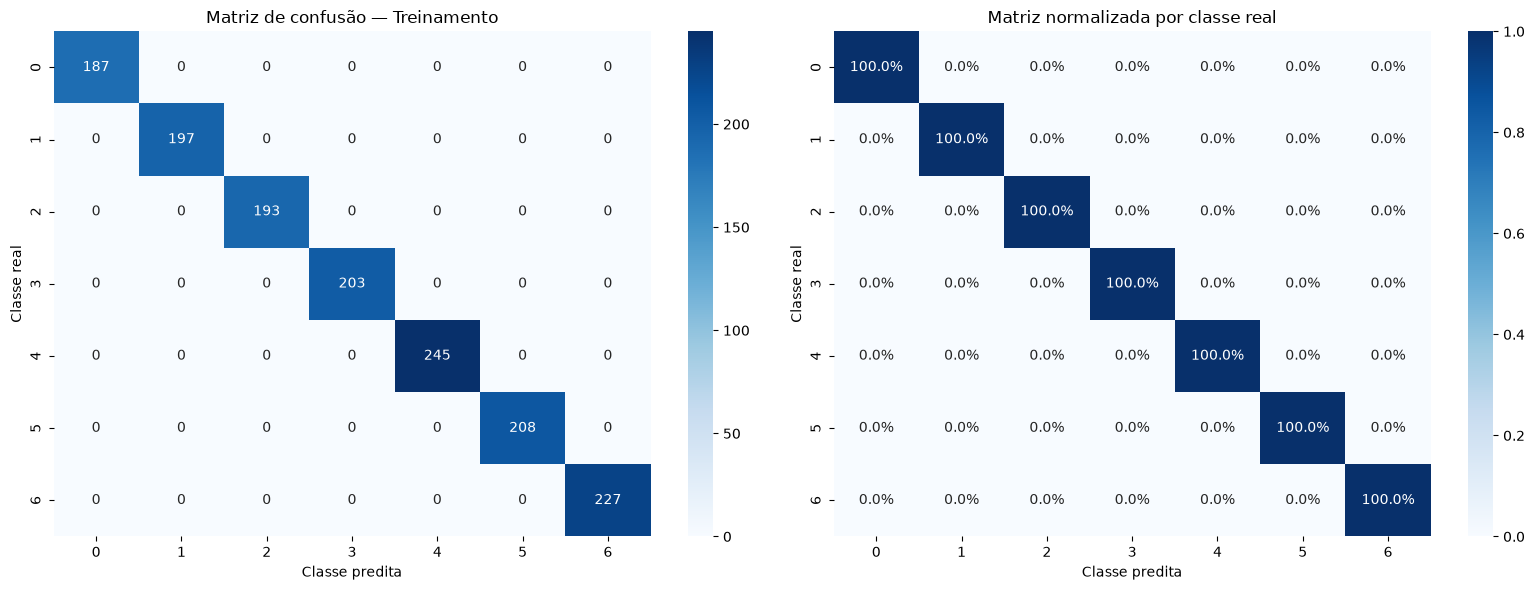

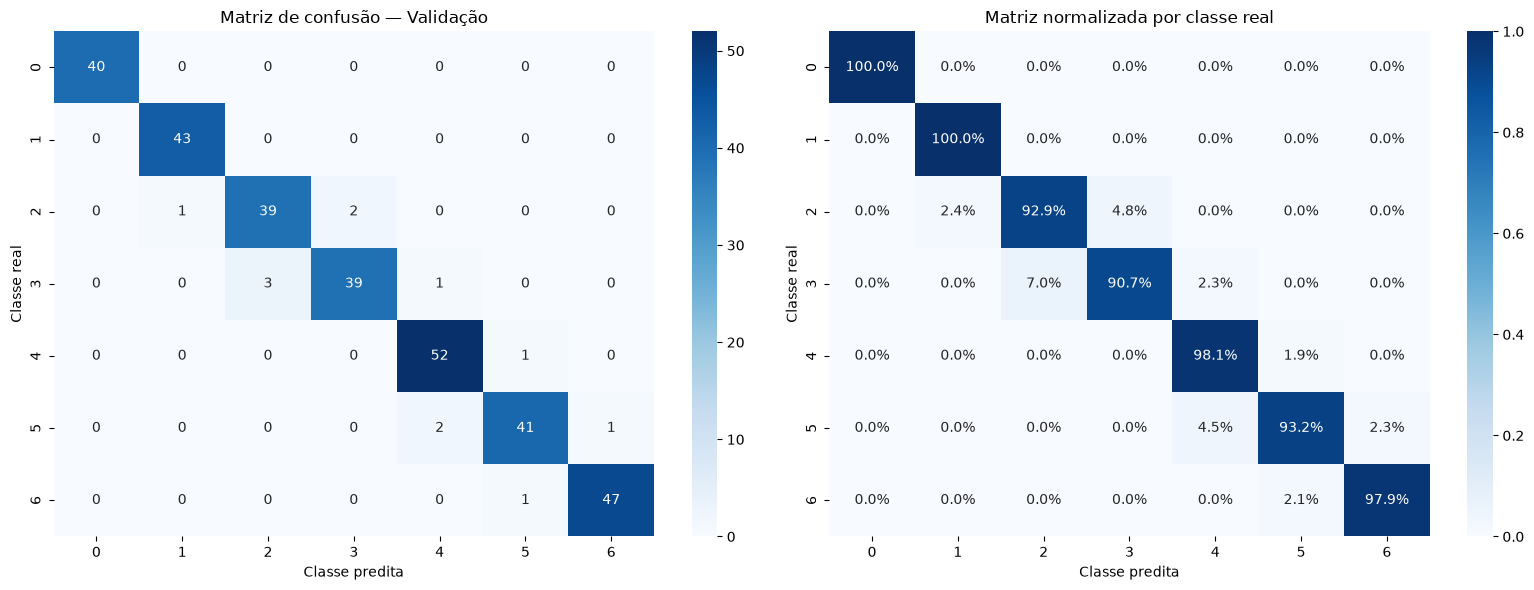

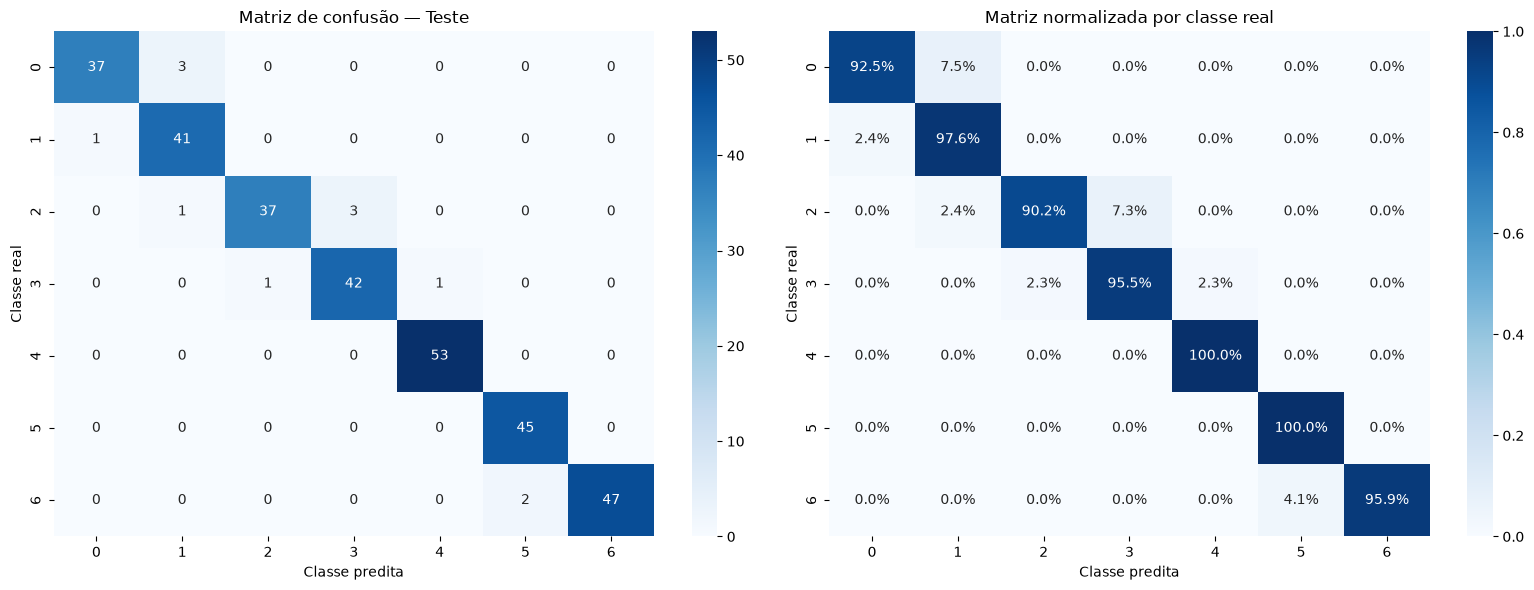

In [77]:
matriz_confusao_obsidade("Treinamento", xgb_final, y_train_xgb, y_train_pred)
matriz_confusao_obsidade("Validação", xgb_final, y_val_xgb, y_val_pred)
matriz_confusao_obsidade("Teste", xgb_final, y_test_xgb, y_test_pred)